In [1]:
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(cowplot)

fp_abinitio = "collected_caprievals/all_caprievals_unrestrained_10k.tsv"
fp_oracle = "collected_caprievals/all_caprievals_oracle_100_10.tsv" 
fp_eval = "collected_caprievals/all_caprievals_eval.tsv"
complexes = dir("data/haddock_units")
complexes



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "1JK9" "1KXP" "1US7" "1Z5Y" "1ZHH" "1ZHI" "2A5T" "2AJF" "2C0L" "2YVJ"
[11] "3PC8" "4H03"

In [2]:
dir.create("collected_caprievals", showWarnings=FALSE)
erase = function(patt, x){gsub(patt, "", x)}

if(!file.exists(fp_abinitio)){
    capri_unrestr_fps = file.path("data/haddock_units", complexes, "haddock_unrestr_10k/7_caprieval/capri_ss.tsv")
    capri_unrestr_fps = capri_unrestr_fps[file.exists(capri_unrestr_fps)]
    capri_unrestr = do.call(rbind,lapply(capri_unrestr_fps, function(fp){
        #fp = capri_oracle_fps[grepl(xname, capri_oracle_fps)]
        xname = erase("^.+/",erase("/+haddock_unrestr_10k/7_caprieval/capri_ss.tsv", fp))
        data = read_tsv(fp, show_col_types=FALSE)%>%
            mutate(complex=xname, run="oracle")%>%
            arrange(score)
        data$score_rank = 1:nrow(data)
        return(data)
    }))
    write_tsv(capri_unrestr, file="collected_caprievals/all_caprievals_unrestrained_10k.tsv")
}

if(!file.exists(fp_oracle)){
    capri_oracle_fps = file.path("data/haddock_units", complexes, "haddock_oracle_100_10/7_caprieval/capri_ss.tsv")
    capri_oracle_fps = capri_oracle_fps[file.exists(capri_oracle_fps)]
    capri_oracle = do.call(rbind,lapply(capri_oracle_fps, function(fp){
        #fp = capri_oracle_fps[grepl(xname, capri_oracle_fps)]
        xname = erase("^.+/",erase("/+haddock_oracle_100_10/7_caprieval/capri_ss.tsv", fp))
        data = read_tsv(fp, show_col_types=FALSE)%>%
            mutate(complex=xname, run="oracle")%>%
            arrange(score)
        data$score_rank = 1:nrow(data)
        return(data)
    }))
    write_tsv(capri_oracle, file="collected_caprievals/all_caprievals_oracle_100_10.tsv")
}

if(!file.exists(fp_eval)){
    capri_eval_fps = file.path("data/haddock_units", complexes, paste0(complexes, "_result.csv")) 
    capri_eval_fps = capri_eval_fps[file.exists(capri_eval_fps)]
    #capri_eval_fps = dir("from_fra", full.names=TRUE)
    erase = function(patt, x) {gsub(patt,"", x)}
    all_res = do.call(rbind, lapply(capri_eval_fps, function(fp){
    	df = read_csv(fp, show_col_type=FALSE)%>%
    		arrange(score)%>%
    		mutate(score_rank = order(score))%>%
            mutate(complex=erase("^.+/|_result.csv",fp))
    }))
    write_tsv(all_res, file="collected_caprievals/all_caprievals_eval.tsv")    
}

In [3]:
res_oracle = read_tsv(fp_oracle, show_col_types=FALSE)%>%
    mutate(run="oracle")%>%as.data.frame()
#res_oracle = read_tsv("collected_caprievals//all_caprievals_oracle_100_10.tsv.tsv", show_col_types=FALSE)%>%
#    mutate(run="oracle")%>%as.data.frame()
res_abinitio = read_tsv(fp_abinitio, show_col_types=FALSE)%>%
    mutate(run="ab-initio")%>%as.data.frame()
res_eval = read_tsv(fp_eval, show_col_types=FALSE)%>%
    mutate(run="eval")

if(any("system" %in% colnames(res_eval))){
    res_eval = res_eval%>%
        rename(complex="system")
}

head(res_oracle, 2)
head(res_abinitio, 2)
head(res_eval, 2)

,model,md5,caprieval_rank,score,irmsd,fnat,lrmsd,ilrmsd,dockq,rmsd,⋯,rdcs,rg,sym,total,vdw,vean,xpcs,complex,run,score_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,../6_seletopclusts/cluster_1_model_1.pdb,-,1,-74.262,2.817,0.209,3.711,3.084,0.423,3.613,⋯,0,0,0,-271.515,-27.263,0,0,1JK9,oracle,1
2,../6_seletopclusts/cluster_1_model_2.pdb,-,2,-74.014,2.683,0.291,2.683,2.590,0.479,3.356,⋯,0,0,0,-270.185,-29.484,0,0,1JK9,oracle,2


,model,md5,caprieval_rank,score,irmsd,fnat,lrmsd,ilrmsd,dockq,rmsd,⋯,rdcs,rg,sym,total,vdw,vean,xpcs,complex,run,score_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,../6_seletopclusts/cluster_2_model_1.pdb,-,1,-78.169,12.339,0.012,21.641,19.850,0.053,12.891,⋯,0,0,0,-300.753,-16.690,0,0,1JK9,ab-initio,1
2,../6_seletopclusts/cluster_1_model_1.pdb,-,2,-69.342,18.756,0.000,55.654,50.251,0.010,19.633,⋯,0,0,0,-281.389,-26.744,0,0,1JK9,ab-initio,2


model,md5,caprieval_rank,score,irmsd,fnat,lrmsd,ilrmsd,dockq,rmsd,⋯,rg,sym,total,vdw,vean,xpcs,provenance,score_rank,complex,run
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
../3_emref/emref_1.pdb,-,1,-88.867,10.257,0.023,20.545,18.574,0.063,11.957,⋯,0,0,-255.406,-42.982,0,0,patches_0_1_1,1,1JK9,eval
../3_emref/emref_1.pdb,-,1,-83.067,10.584,0.000,27.557,25.932,0.036,10.232,⋯,0,0,-257.619,-28.392,0,0,patches_1_1_1,2,1JK9,eval


In [4]:
################################################# PLOTTING RESULTS
### 1) RMSD vs IRMSD values
#### MANUAL PERMANENT PALETTE:
### complex_colors = c()
complexes = c('1JK9','1KXP','1US7','1Z5Y','1ZHH','1ZHI','2A5T','2AJF','2C0L','2GAF','2YVJ','3PC8','4H03')

hex_colors <- c("#70A8CE", "#FFB26E", "#88C588", "#E67D7E", "#BDA3D6", "#BA9993", "#EEADDA")
hex_light2 <- colorRampPalette(c("white", "white"))(7)  # placeholder
hex_light2 <- sapply(hex_colors, function(c) colorRampPalette(c(c, "#FFFFFF"))(3)[2])

permanent_palette = c(hex_colors, hex_light2)
names(permanent_palette) = complexes
permanent_palette = permanent_palette[complexes]
permanent_palette

1JK9      1KXP      1US7      1Z5Y      1ZHH      1ZHI      2A5T      2AJF 
"#70A8CE" "#FFB26E" "#88C588" "#E67D7E" "#BDA3D6" "#BA9993" "#EEADDA" "#B7D3E6" 
     2C0L      2GAF      2YVJ      3PC8      4H03 
"#FFD8B6" "#C3E2C3" "#F2BEBE" "#DED1EA" "#DCCCC9"

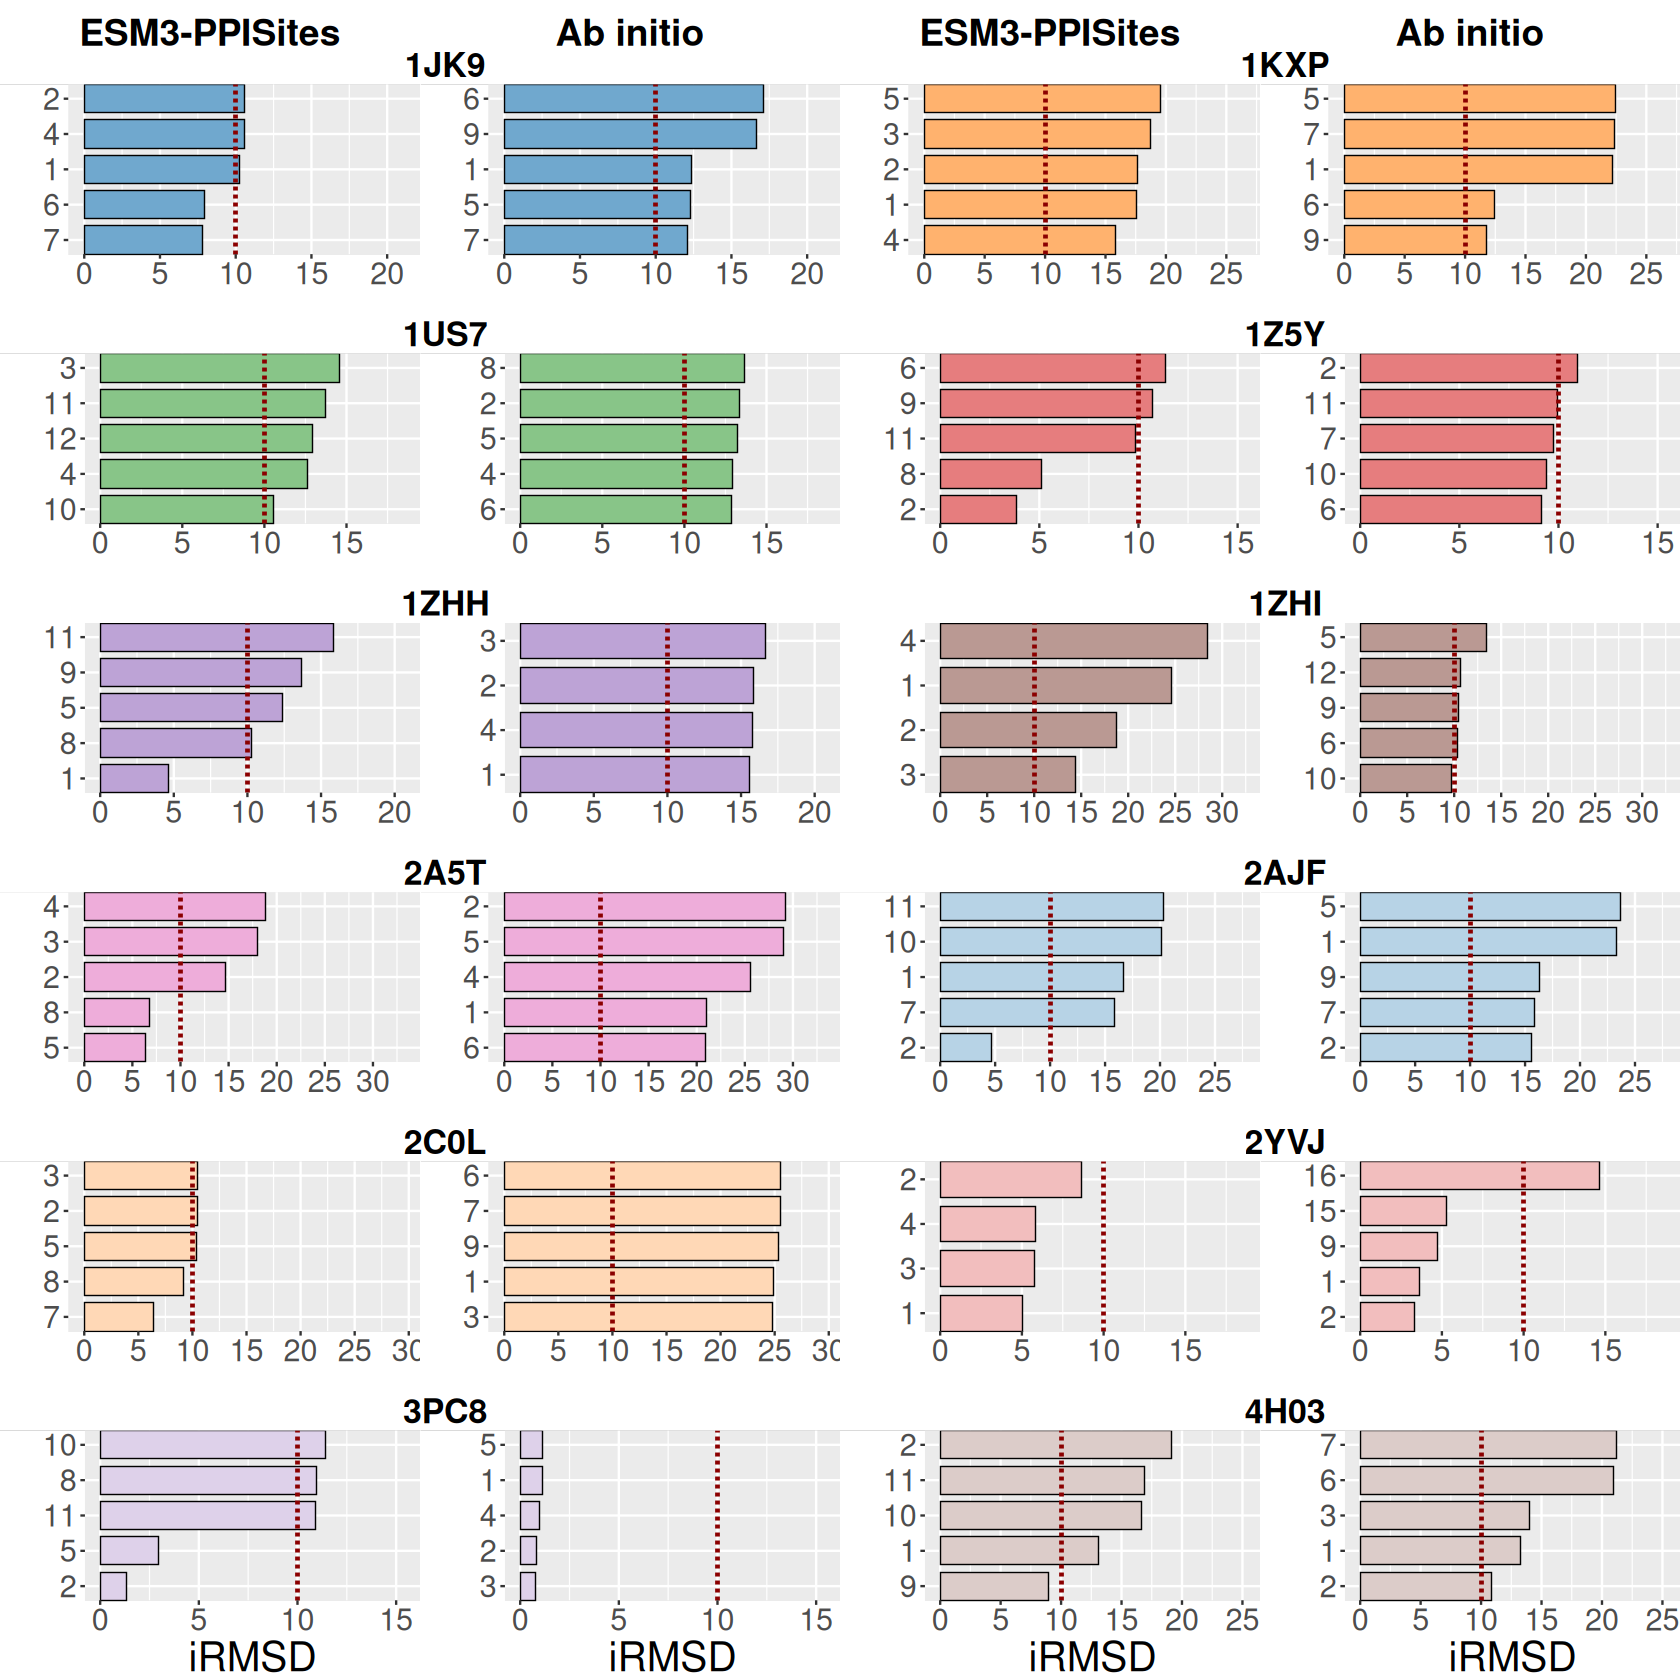

In [5]:
library(cowplot)
library(ggplot2)
library(dplyr)

top_n = 5
complexes = c('1JK9','1KXP','1US7','1Z5Y','1ZHH','1ZHI','2A5T','2AJF','2C0L','2YVJ','3PC8','4H03')
bar_panels = list()
bar_width = 0.8

for(my_complex in complexes){
    
    df = res_abinitio %>%
        filter(complex == my_complex) %>%
        arrange(irmsd) %>% head(top_n) %>% 
        mutate(y = paste0(complex, "_", score_rank))
    
    p_bars_abinitio = ggplot() +
        geom_col(data = df, color = "black", linewidth = 0.3, width = bar_width, aes(
            y = reorder(as.integer(score_rank), irmsd), x = irmsd, fill = complex)) +
        labs(x = "iRMSD", y = "") +
        ggtitle(my_complex)
    max_abinitio = max(df$irmsd)
    
    df = res_eval %>%
        filter(complex == my_complex) %>%
        arrange(irmsd) %>% head(top_n) %>% 
        mutate(y = paste0(complex, "_", score_rank))
    
    max_eval = max(df$irmsd)
    p_bars_eval = ggplot() +
        geom_col(data = df, color = "black", linewidth = 0.3, width = bar_width, aes(
            y = reorder(as.integer(score_rank), irmsd), x = irmsd, fill = complex)) +
        labs(x = "iRMSD", y = "") 
    max_both = max(max_abinitio, max_eval)
    
    bplot_list = list(p_bars_eval, p_bars_abinitio)
    bplot_list = lapply(bplot_list, function(myp){
        myp +
            geom_vline(xintercept = 10, linetype = "dashed", linewidth = 1, color = "darkred") +
            scale_x_continuous(limits = c(0, max_both + 4), breaks = seq(0, 30, by = 5)) +
            scale_y_discrete(expand = expansion(add = c(0.2, 0.2))) +
            scale_fill_manual(values = permanent_palette) +
            theme(legend.position = "none",
                  plot.title = element_text(hjust = 2, size = 20, face = "bold"), 
                  axis.title = element_text(size = 24),           
                  axis.text = element_text(size = 18),              
                  strip.text = element_text(size = 16))
    })
    bar_panels[[my_complex]] = bplot_list 
}

bar_panels = unlist(bar_panels, recursive = FALSE)

for(i in seq_along(bar_panels)){
    if(i %% 2 != 1) {
        bar_panels[[i]] = bar_panels[[i]] + labs(y = "")
    }
    if(i < length(bar_panels) - 3){
        bar_panels[[i]] = bar_panels[[i]] + labs(x = "")
    }
    bar_panels[[i]] = bar_panels[[i]] + 
        theme(plot.margin = margin(t = 0, r = 0, b = 0, l = 0, unit = "pt"))
}

# ---- 4-COLUMN LAYOUT: TWO COUPLES SIDE BY SIDE ----

# Remove individual plot titles
for(i in seq_along(bar_panels)){
    bar_panels[[i]] = bar_panels[[i]] + ggtitle(NULL)
}

# Build "couples": each couple = one complex with eval + abinitio (2 columns)
# Then place two couples side by side (4 columns total)
# Complexes per row: 2 couples = 4 plots wide
complexes_per_row = 2
n_rows = ceiling(length(complexes) / complexes_per_row)

all_rows = list()

for(r in seq_len(n_rows)){
    
    couple_plots = list()
    couple_titles = list()
    
    for(c in 1:complexes_per_row){
        idx_complex = (r - 1) * complexes_per_row + c
        if(idx_complex > length(complexes)) break
        
        comp = complexes[idx_complex]
        idx1 = 2 * idx_complex - 1   
        idx2 = 2 * idx_complex       
        
        # Single couple: eval + abinitio side by side
        couple = plot_grid(bar_panels[[idx1]], bar_panels[[idx2]],
                           ncol = 2, align = "hv", axis = "tblr",
                           rel_widths = c(1, 1))
        
        # Add a border/frame around each couple
        couple = couple + theme(plot.background = element_rect(color = "black", linewidth = 1, fill = NA))
        
        # Complex name above the couple
        couple_title = ggdraw() + 
            draw_label(comp, size = 20, fontface = "bold", x = 0.53, y = 1) +
            theme(panel.background = element_rect(fill = "white", color = NA),
                  plot.background = element_rect(fill = "white", color = NA))
        
        couple_with_title = plot_grid(couple_title, couple,
                                      ncol = 1, rel_heights = c(0.08, 1),
                                      greedy = FALSE)
        
        couple_plots[[c]] = couple_with_title
        couple_titles[[c]] = comp
    }
    
    # Assemble the two couples side by side (4 columns total)
    if(length(couple_plots) == 2){
        row_plot = plot_grid(couple_plots[[1]], couple_plots[[2]],
                             ncol = 2, rel_widths = c(1, 1), greedy = FALSE)
    } else {
        row_plot = couple_plots[[1]]
    }
    
    all_rows[[r]] = row_plot
}

# Column headers: 4 columns = ESM3-PPISites | Ab-initio | ESM3-PPISites | Ab-initio
col_header = plot_grid(
    ggdraw() + draw_label("ESM3-PPISites", size = 22, fontface = "bold", x = 0.5, y = 0.5) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)),
    ggdraw() + draw_label("Ab initio", size = 22, fontface = "bold", x = 0.5, y = 0.5) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)),
    ggdraw() + draw_label("ESM3-PPISites", size = 22, fontface = "bold", x = 0.5, y = 0.5) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)),
    ggdraw() + draw_label("Ab initio", size = 22, fontface = "bold", x = 0.5, y = 0.5) +
        theme(panel.background = element_rect(fill = "white", color = NA),
              plot.background = element_rect(fill = "white", color = NA)),
    ncol = 4, rel_widths = c(1, 1, 1, 1)
)

# Assemble everything
final_plot = plot_grid(col_header, plot_grid(plotlist = all_rows, ncol = 1, greedy = FALSE),
                       ncol = 1, rel_heights = c(0.04, 1), greedy = FALSE)

# Wider figure to accommodate 4 columns
options(repr.plot.height = 14, repr.plot.width = 14)
print(final_plot)
dir.create("PPI_plots", showWarnings=FALSE)
ggsave(final_plot, file="PPI_plots/ESM3-PPISites_vs_Ab-initio_4cols.png", height=14, width=14)

In [6]:
decompose <- function(lines) {
  pattern       <- "=== Processing:"
  match_indices <- grep(pattern, lines)
  
  if (length(match_indices) == 0) {
    return(list(lines))
  }
  
  breakpoints <- c(match_indices, length(lines) + 1)
  
  result <- list()
  nomi   <- character()
  
  for (i in seq_len(length(breakpoints) - 1)) {
    start <- breakpoints[i]
    end   <- breakpoints[i + 1] - 1
    
    block    <- lines[start:end]
    run_name <- sub(".*=== Processing: (\\S+) .*", "\\1", lines[start])
    
    result[[length(result) + 1]] <- block
    nomi <- c(nomi, run_name)
  }
  
  names(result) <- nomi
  return(result)
}


decompose_eval <- function(lines) {
  # Pattern matches: data/haddock_units/XXXX/configs/patches_X_X_X.cfg
  pattern       <- "^data/haddock_units/[^/]+/configs/patches_[0-9]+_[0-9]+_[0-9]+\\.cfg$"
  match_indices <- grep(pattern, lines)
  
  if (length(match_indices) == 0) {
    return(list(lines))
  }
  
  breakpoints <- c(match_indices, length(lines) + 1)
  
  result <- list()
  nomi   <- character()
  
  for (i in seq_len(length(breakpoints) - 1)) {
    start <- breakpoints[i]
    end   <- breakpoints[i + 1] - 1
    
    block    <- lines[start:end]
    # Extract run name: e.g., "1JK9/patches_0_0_0" from the config path
    run_name <- sub(".*data/haddock_units/([^/]+)/configs/(patches_[0-9]+_[0-9]+_[0-9]+)\\.cfg.*", 
                    "\\1/\\2", lines[start])
    
    result[[length(result) + 1]] <- block
    nomi <- c(nomi, run_name)
  }
  
  names(result) <- nomi
  return(result)
}

In [7]:
log_file_abinitio = readLines("logs_abinitio/log_abinitio_10k_haddock_1251429.out")

log_list = decompose(lines=log_file_abinitio)
#log_list[[1]]

parsed_logs <- lapply(names(log_list), function(jobname) {
  x <- log_list[[jobname]]
  # job start from header line
  job_start <- as.POSIXct(
    sub(".*Started: ([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}) .*", "\\1", x[1]),
    format = "%Y-%m-%d %H:%M:%S"
  )
  # lines where modules finish
  module_lines <- x[grepl("Module .+ finished", x)]
  # extract module name and end timestamp from each line
  modules <- sub(".*Module \\[(.+)\\] finished.*", "\\1", module_lines)
  ends    <- as.POSIXct(
    sub("\\[([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}).*", "\\1", module_lines),
    format = "%Y-%m-%d %H:%M:%S"
  )
  # start of each module = job_start for the first, end of previous for the rest
  starts <- c(job_start, ends[-length(ends)])
  data.frame(
    jobname  = jobname,
    module   = modules,
    start    = starts,
    end      = ends,
    duration = as.numeric(difftime(ends, starts, units = "secs")),
    stringsAsFactors = FALSE
  )
})
#parsed_logs[[1]]
data_abinitio = data.frame(do.call(rbind, parsed_logs))%>%
    mutate(runtype='Ab initio')

head(data_abinitio)

,jobname,module,start,end,duration,runtype
,<chr>,<chr>,<dttm>,<dttm>,<dbl>,<chr>
1,1JK9,topoaa,2026-06-06 15:39:44,2026-06-06 15:39:53,9,Ab initio
2,1JK9,rigidbody,2026-06-06 15:39:53,2026-06-06 15:52:11,738,Ab initio
3,1JK9,seletop,2026-06-06 15:52:11,2026-06-06 15:52:12,1,Ab initio
4,1JK9,flexref,2026-06-06 15:52:12,2026-06-06 15:54:21,129,Ab initio
5,1JK9,emref,2026-06-06 15:54:21,2026-06-06 15:54:35,14,Ab initio
6,1JK9,clustfcc,2026-06-06 15:54:35,2026-06-06 15:54:36,1,Ab initio


In [8]:
log_file_oracle = readLines("logs_oracle/log_oracle_rig100_top10_haddock_1251321.out")

log_list = decompose(lines=log_file_oracle)

parsed_logs <- lapply(names(log_list), function(jobname) {
  x <- log_list[[jobname]]
  # job start from header line
  job_start <- as.POSIXct(
    sub(".*Started: ([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}) .*", "\\1", x[1]),
    format = "%Y-%m-%d %H:%M:%S"
  )
  # lines where modules finish
  module_lines <- x[grepl("Module .+ finished", x)]
  # extract module name and end timestamp from each line
  modules <- sub(".*Module \\[(.+)\\] finished.*", "\\1", module_lines)
  ends    <- as.POSIXct(
    sub("\\[([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}).*", "\\1", module_lines),
    format = "%Y-%m-%d %H:%M:%S"
  )
  # start of each module = job_start for the first, end of previous for the rest
  starts <- c(job_start, ends[-length(ends)])
  data.frame(
    jobname  = jobname,
    module   = modules,
    start    = starts,
    end      = ends,
    duration = as.numeric(difftime(ends, starts, units = "secs")),
    stringsAsFactors = FALSE
  )
})
#parsed_logs[[1]]
data_oracle = data.frame(do.call(rbind, parsed_logs))%>%
    mutate(runtype='Oracle')

head(data_oracle)

,jobname,module,start,end,duration,runtype
,<chr>,<chr>,<dttm>,<dttm>,<dbl>,<chr>
1,1JK9,topoaa,2026-06-06 15:34:39,2026-06-06 15:36:09,90,Oracle
2,1JK9,rigidbody,2026-06-06 15:36:09,2026-06-06 15:36:20,11,Oracle
3,1JK9,seletop,2026-06-06 15:36:20,2026-06-06 15:36:20,0,Oracle
4,1JK9,flexref,2026-06-06 15:36:20,2026-06-06 15:36:56,36,Oracle
5,1JK9,emref,2026-06-06 15:36:56,2026-06-06 15:37:00,4,Oracle
6,1JK9,clustfcc,2026-06-06 15:37:00,2026-06-06 15:37:01,1,Oracle


In [9]:
log_file_eval = readLines("logs_eval/log_eval_1251407.out")
log_list = decompose_eval(lines=log_file_eval)

parsed_logs <- lapply(names(log_list), function(jobname) {
  x <- log_list[[jobname]]
  
  # Extract all timestamps from the block
  all_timestamps <- as.POSIXct(
    sub("\\[([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}).*", "\\1", 
        x[grepl("\\[20[0-9]{2}-[0-9]{2}-[0-9]{2}", x)]),
    format = "%Y-%m-%d %H:%M:%S"
  )
  job_start <- min(all_timestamps, na.rm = TRUE)
  
  # Lines where modules finish
  module_lines <- x[grepl("Module .+ finished", x)]
  modules <- sub(".*Module \\[(.+)\\] finished.*", "\\1", module_lines)
  ends    <- as.POSIXct(
    sub("\\[([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}).*", "\\1", module_lines),
    format = "%Y-%m-%d %H:%M:%S"
  )
  
  # start of each module = job_start for the first, end of previous for the rest
  starts <- c(job_start, ends[-length(ends)])
  
  data.frame(
    jobname  = jobname,
    module   = modules,
    start    = starts,
    end      = ends,
    duration = as.numeric(difftime(ends, starts, units = "secs")),
    stringsAsFactors = FALSE
  )
})
#parsed_logs[[1]]
data_eval = data.frame(do.call(rbind, parsed_logs))%>%
    mutate(runtype='ESM3-PPISites')

head(data_eval)

,jobname,module,start,end,duration,runtype
,<chr>,<chr>,<dttm>,<dttm>,<dbl>,<chr>
1,1JK9/patches_0_0_0,topoaa,2026-06-06 15:38:17,2026-06-06 15:38:21,4,ESM3-PPISites
2,1JK9/patches_0_0_0,rigidbody,2026-06-06 15:38:21,2026-06-06 15:38:30,9,ESM3-PPISites
3,1JK9/patches_0_0_0,seletop,2026-06-06 15:38:30,2026-06-06 15:38:30,0,ESM3-PPISites
4,1JK9/patches_0_0_0,emref,2026-06-06 15:38:30,2026-06-06 15:38:33,3,ESM3-PPISites
5,1JK9/patches_0_0_0,caprieval,2026-06-06 15:38:33,2026-06-06 15:38:33,0,ESM3-PPISites
6,1JK9/patches_0_0_1,topoaa,2026-06-06 15:38:36,2026-06-06 15:38:40,4,ESM3-PPISites


In [10]:
data_all = rbind(data_oracle, data_eval, data_abinitio)%>%
    mutate(copy_jobname = jobname)%>%
    mutate(jobname = gsub("/.+$","",jobname))%>%
    group_by(jobname, runtype)%>%
    summarize(minutes = ceiling(sum(duration)/60), .groups="drop")
head(data_all)


jobname,runtype,minutes
<chr>,<chr>,<dbl>
1JK9,Ab initio,15
1JK9,ESM3-PPISites,3
1JK9,Oracle,3
1KXP,Ab initio,37
1KXP,ESM3-PPISites,5
1KXP,Oracle,3



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




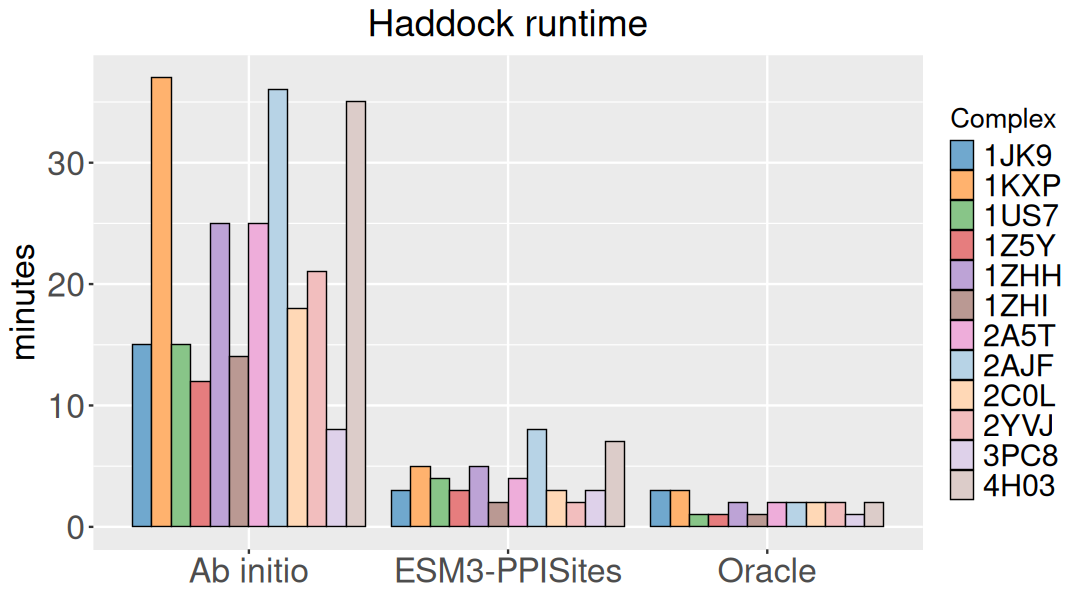

In [11]:
library(ggplot2)
library(scales)

options(repr.plot.height=5, repr.plot.width=8)

p_timing = ggplot() +
    geom_col(data=data_all, color = "black", linewidth = 0.3, position = "dodge",
             aes(x=runtype, y=minutes, group=jobname, fill=jobname)) +
    scale_fill_manual(values=permanent_palette) +
    ggtitle("Haddock runtime") +
    labs(x = NULL, fill = "Complex") + # Removes x title, changes legend title
    theme(
          plot.title = element_text(hjust = 0.5, size = 22),
          axis.title = element_text(size = 20),       
          axis.text = element_text(size = 20),                  
          strip.text = element_text(size = 16)) +
    theme(
        legend.position = "right",
        legend.title = element_text(size = 16),       # Un-commented if you want to style it
        legend.text = element_text(size = 18),        # bigger labels
        legend.key.size = unit(0.5, "cm"),            # bigger color keys
        legend.spacing.y = unit(0.5, "cm")            # more vertical spacing
    )

outdir = "PPI_plots"
ggsave(filename=file.path(outdir, "haddock_runtime.png"), width=7, height=5)

options(repr.plot.height=5, repr.plot.width=9)
p_timing